# Week 6 - Exercises

## Exercise 1: Mixing patterns and assortativity

### Part 1: Assortativity Coefficient

In [1]:
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from networkx.readwrite import json_graph

# load the network
with open("week4_css_network.json") as f:
    G_data = json.load(f)

G = json_graph.node_link_graph(G_data)
print(G)

Graph with 18307 nodes and 73938 edges


In [2]:
# extract the giant connected component (GCC)
gcc_nodes = max(nx.connected_components(G), key=len)
GCC = G.subgraph(gcc_nodes).copy()
print(f"GCC: {GCC.number_of_nodes()} nodes, {GCC.number_of_edges()} edges")

GCC: 17802 nodes, 72800 edges


In [3]:
# get country for each node in GCC
country = nx.get_node_attributes(GCC, "country")

# check how many nodes have a country
has_country = {n for n, c in country.items() if c is not None and c is not np.nan and str(c) != "nan"}
print(f"Nodes with country: {len(has_country)} / {GCC.number_of_nodes()}")

Nodes with country: 14904 / 17802


In [4]:
# count edges by country pair (only where both have country)
from collections import Counter

edge_counts = Counter()
total_edges = 0

for u, v in GCC.edges():
    cu = country.get(u)
    cv = country.get(v)
    if cu is not None and cv is not None and str(cu) != "nan" and str(cv) != "nan":
        edge_counts[(cu, cv)] += 1
        edge_counts[(cv, cu)] += 1  # count both directions for undirected
        total_edges += 1

print(f"Edges with both countries: {total_edges}")
print(f"Unique countries: {len(set(c for pair in edge_counts for c in pair))}")

Edges with both countries: 52462
Unique countries: 118


In [5]:
# get all unique countries
countries = sorted(set(c for pair in edge_counts for c in pair))

# e_ij = fraction of edges connecting type i to type j
# since we double-counted (both directions), divide by 2 * total_edges
# actually we counted each edge twice in edge_counts, so the total sum of edge_counts = 2 * total_edges
total_2 = 2 * total_edges  # sum of all edge_counts values

# e_ii = fraction of edges where both endpoints are same country
e_ii_sum = sum(edge_counts[(c, c)] for c in countries) / total_2

# a_i = fraction of edge endpoints that are country i
# for undirected: a_i = b_i = sum_j(e_ij)
a = {}
for c in countries:
    a[c] = sum(edge_counts[(c, c2)] for c2 in countries) / total_2

a_sq_sum = sum(a[c] ** 2 for c in countries)

# assortativity
r = (e_ii_sum - a_sq_sum) / (1 - a_sq_sum)
print(f"Assortativity (country): {r:.4f}")

Assortativity (country): 0.3766


### Part 2: Configuration model

In [6]:
def compute_country_assortativity(G, country_attr="country"):
    """Compute assortativity coefficient by country attribute."""
    country = nx.get_node_attributes(G, country_attr)
    
    edge_counts = Counter()
    total_edges = 0
    
    for u, v in G.edges():
        cu = country.get(u)
        cv = country.get(v)
        if cu is not None and cv is not None and str(cu) != "nan" and str(cv) != "nan":
            edge_counts[(cu, cv)] += 1
            edge_counts[(cv, cu)] += 1
            total_edges += 1
    
    if total_edges == 0:
        return 0
    
    countries = sorted(set(c for pair in edge_counts for c in pair))
    total_2 = 2 * total_edges
    
    e_ii_sum = sum(edge_counts[(c, c)] for c in countries) / total_2
    a = {c: sum(edge_counts[(c, c2)] for c2 in countries) / total_2 for c in countries}
    a_sq_sum = sum(v ** 2 for v in a.values())
    
    return (e_ii_sum - a_sq_sum) / (1 - a_sq_sum)

# verify it matches
print(compute_country_assortativity(GCC))

0.3765799903340637


In [7]:
import random

def double_edge_swap(G, n_swaps=None):
    """Create a randomized copy using double edge swap algorithm."""
    R = G.copy()
    edges = list(R.edges())
    E = len(edges)
    
    if n_swaps is None:
        n_swaps = E * 10
    
    swaps_done = 0
    attempts = 0
    max_attempts = n_swaps * 10  # safety limit
    
    while swaps_done < n_swaps and attempts < max_attempts:
        attempts += 1
        
        # b. pick two random edges
        idx1, idx2 = random.sample(range(len(edges)), 2)
        u, v = edges[idx1]
        x, y = edges[idx2]
        
        # c. flip e1 50% of the time
        if random.random() < 0.5:
            u, v = v, u
        
        # check u != y and v != x
        if u == y or v == x:
            continue
        
        # also avoid self-loops
        if u == x or v == y:
            continue
        
        # d. check new edges don't already exist
        if R.has_edge(u, y) or R.has_edge(x, v):
            continue
        
        # e. perform the swap
        R.remove_edge(edges[idx1][0], edges[idx1][1])
        R.remove_edge(edges[idx2][0], edges[idx2][1])
        R.add_edge(u, y)
        R.add_edge(x, v)
        
        # update edge list
        edges[idx1] = (u, y)
        edges[idx2] = (x, v)
        
        swaps_done += 1
    
    print(f"Swaps completed: {swaps_done}/{n_swaps} (attempts: {attempts})")
    return R

# test it
R_test = double_edge_swap(GCC)

Swaps completed: 728000/728000 (attempts: 732987)


In [8]:
# check that degree sequence is identical
orig_degrees = sorted(dict(GCC.degree()).values())
rand_degrees = sorted(dict(R_test.degree()).values())

print(f"Degree sequences match: {orig_degrees == rand_degrees}")

Degree sequences match: True


### Part 3: Analyzing Assortativity in Random Networks

In [9]:
from joblib import Parallel, delayed

def swap_and_compute(G, i):
    R = double_edge_swap(G)
    r = compute_country_assortativity(R)
    return r

# this will take a while — 100 networks × ~728k swaps each
random_assortativities = Parallel(n_jobs=5, verbose=5)(
    delayed(swap_and_compute)(GCC, i) for i in range(100)
)

print(f"Done! Mean: {np.mean(random_assortativities):.4f}, Std: {np.std(random_assortativities):.4f}")

[Parallel(n_jobs=5)]: Using backend LokyBackend with 5 concurrent workers.


Swaps completed: 728000/728000 (attempts: 733013)
Swaps completed: 728000/728000 (attempts: 732978)
Swaps completed: 728000/728000 (attempts: 733107)
Swaps completed: 728000/728000 (attempts: 733029)
Swaps completed: 728000/728000 (attempts: 732913)
Swaps completed: 728000/728000 (attempts: 733069)
Swaps completed: 728000/728000 (attempts: 732924)
Swaps completed: 728000/728000 (attempts: 732981)


[Parallel(n_jobs=5)]: Done   8 tasks      | elapsed:    8.1s


Swaps completed: 728000/728000 (attempts: 733015)
Swaps completed: 728000/728000 (attempts: 732885)
Swaps completed: 728000/728000 (attempts: 732913)
Swaps completed: 728000/728000 (attempts: 733075)
Swaps completed: 728000/728000 (attempts: 733003)
Swaps completed: 728000/728000 (attempts: 732796)
Swaps completed: 728000/728000 (attempts: 733050)
Swaps completed: 728000/728000 (attempts: 732953)
Swaps completed: 728000/728000 (attempts: 732908)
Swaps completed: 728000/728000 (attempts: 732934)
Swaps completed: 728000/728000 (attempts: 732955)
Swaps completed: 728000/728000 (attempts: 732887)
Swaps completed: 728000/728000 (attempts: 732852)
Swaps completed: 728000/728000 (attempts: 732910)
Swaps completed: 728000/728000 (attempts: 732949)
Swaps completed: 728000/728000 (attempts: 732877)
Swaps completed: 728000/728000 (attempts: 732969)
Swaps completed: 728000/728000 (attempts: 732920)
Swaps completed: 728000/728000 (attempts: 732924)
Swaps completed: 728000/728000 (attempts: 732967)


[Parallel(n_jobs=5)]: Done  62 tasks      | elapsed:   52.0s


Swaps completed: 728000/728000 (attempts: 733016)
Swaps completed: 728000/728000 (attempts: 732986)
Swaps completed: 728000/728000 (attempts: 732947)
Swaps completed: 728000/728000 (attempts: 732955)
Swaps completed: 728000/728000 (attempts: 732931)
Swaps completed: 728000/728000 (attempts: 732980)
Swaps completed: 728000/728000 (attempts: 733000)
Swaps completed: 728000/728000 (attempts: 732883)
Swaps completed: 728000/728000 (attempts: 732972)
Swaps completed: 728000/728000 (attempts: 732952)
Swaps completed: 728000/728000 (attempts: 732877)
Swaps completed: 728000/728000 (attempts: 732999)
Swaps completed: 728000/728000 (attempts: 732882)
Swaps completed: 728000/728000 (attempts: 732844)
Swaps completed: 728000/728000 (attempts: 732920)
Swaps completed: 728000/728000 (attempts: 732892)
Swaps completed: 728000/728000 (attempts: 733008)
Swaps completed: 728000/728000 (attempts: 733033)
Swaps completed: 728000/728000 (attempts: 732955)
Swaps completed: 728000/728000 (attempts: 733066)


[Parallel(n_jobs=5)]: Done 100 out of 100 | elapsed:  1.3min finished


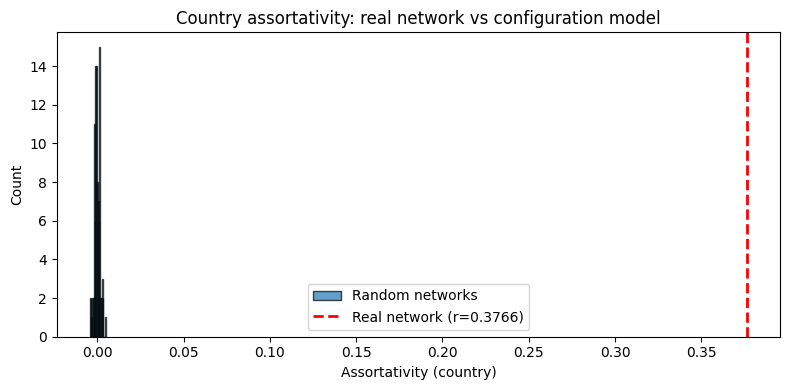

In [10]:
real_r = compute_country_assortativity(GCC)

plt.figure(figsize=(8, 4))
plt.hist(random_assortativities, bins=20, edgecolor="black", alpha=0.7, label="Random networks")
plt.axvline(real_r, color="red", linewidth=2, linestyle="--", label=f"Real network (r={real_r:.4f})")
plt.xlabel("Assortativity (country)")
plt.ylabel("Count")
plt.title("Country assortativity: real network vs configuration model")
plt.legend()
plt.tight_layout()
plt.show()

### Part 4: Degree assortativity

In [11]:
def compute_degree_assortativity(G):
    """Compute degree assortativity using Pearson correlation of degrees at edge endpoints."""
    edges = list(G.edges())
    deg = dict(G.degree())
    
    x = np.array([deg[u] for u, v in edges])
    y = np.array([deg[v] for u, v in edges])
    
    # symmetric — count both directions
    x_all = np.concatenate([x, y])
    y_all = np.concatenate([y, x])
    
    mean_x = np.mean(x_all)
    mean_y = np.mean(y_all)
    
    numerator = np.mean(x_all * y_all) - mean_x * mean_y
    denominator = np.sqrt((np.mean(x_all**2) - mean_x**2) * (np.mean(y_all**2) - mean_y**2))
    
    return numerator / denominator

r_degree = compute_degree_assortativity(GCC)
print(f"Degree assortativity: {r_degree:.4f}")

Degree assortativity: -0.0820


In [12]:
def double_edge_swap(G, n_swaps=None):
    """Create a randomized copy using double edge swap algorithm."""
    R = G.copy()
    edges = list(R.edges())
    E = len(edges)
    
    if n_swaps is None:
        n_swaps = E * 10
    
    swaps_done = 0
    attempts = 0
    max_attempts = n_swaps * 10
    
    while swaps_done < n_swaps and attempts < max_attempts:
        attempts += 1
        
        idx1, idx2 = random.sample(range(len(edges)), 2)
        e1 = edges[idx1]
        e2 = edges[idx2]
        
        u, v = e1
        x, y = e2
        
        if random.random() < 0.5:
            u, v = v, u
        
        if u == y or v == x or u == x or v == y:
            continue
        
        if R.has_edge(u, y) or R.has_edge(x, v):
            continue
        
        # verify edges still exist before removing
        if not R.has_edge(*e1) or not R.has_edge(*e2):
            # edge list out of sync — refresh it
            edges = list(R.edges())
            continue
        
        R.remove_edge(*e1)
        R.remove_edge(*e2)
        R.add_edge(u, y)
        R.add_edge(x, v)
        
        edges[idx1] = (u, y)
        edges[idx2] = (x, v)
        
        swaps_done += 1
    
    return R

def swap_and_compute_degree(G, i):
    R = double_edge_swap(G)
    return compute_degree_assortativity(R)

random_degree_assort = Parallel(n_jobs=5, verbose=5)(
    delayed(swap_and_compute_degree)(GCC, i) for i in range(100)
)

print(f"Done! Mean: {np.mean(random_degree_assort):.4f}, Std: {np.std(random_degree_assort):.4f}")

[Parallel(n_jobs=5)]: Using backend LokyBackend with 5 concurrent workers.
[Parallel(n_jobs=5)]: Done   8 tasks      | elapsed:    8.3s
[Parallel(n_jobs=5)]: Done  62 tasks      | elapsed:   53.3s


Done! Mean: -0.0100, Std: 0.0027


[Parallel(n_jobs=5)]: Done 100 out of 100 | elapsed:  1.4min finished


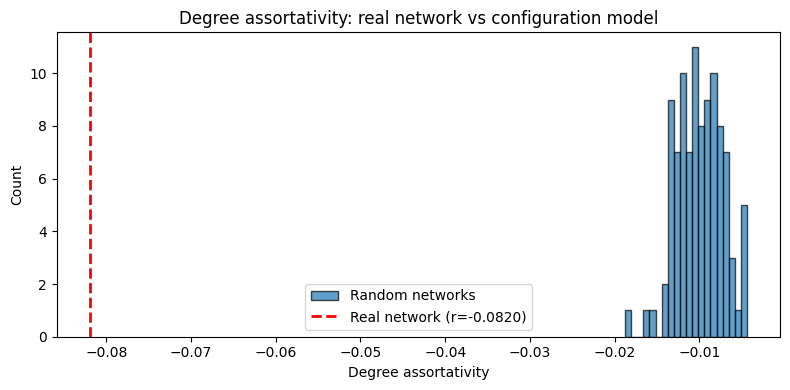

In [13]:
plt.figure(figsize=(8, 4))
plt.hist(random_degree_assort, bins=20, edgecolor="black", alpha=0.7, label="Random networks")
plt.axvline(r_degree, color="red", linewidth=2, linestyle="--", label=f"Real network (r={r_degree:.4f})")
plt.xlabel("Degree assortativity")
plt.ylabel("Count")
plt.title("Degree assortativity: real network vs configuration model")
plt.legend()
plt.tight_layout()
plt.show()

**7. Degree assortativity — expected?**

the negative degree assortativity (-0.082) makes sense for a co-authorship network. 
prolific researchers (high degree) tend to collaborate with many different people, 
including less-connected researchers like phd students and postdocs. this creates a 
hub-and-spoke pattern where high-degree nodes connect to many low-degree nodes rather 
than forming an exclusive club of highly connected scientists.

**8. Edge flipping — why?**

when we build the edge list from the graph, edges are often stored in a sorted order 
(e.g. alphabetically by node id). if we always pick e1 = (u,v) without flipping, the 
new edges e1' = (u, y) and e2' = (x, v) would inherit this sorting bias — u would 
always be the "earlier" node. flipping e1 50% of the time removes this bias and ensures 
the rewiring is truly random.

**9. Distribution of random assortativity**

the random networks show degree assortativity tightly clustered around -0.01, with a 
small standard deviation (~0.003). the slight negative value is expected because the 
configuration model preserves the degree sequence, which is heavy-tailed — high-degree 
nodes simply have more edges, so they're statistically more likely to connect to 
low-degree nodes even by chance. the tight distribution reflects the law of large 
numbers: with ~73k edges, each randomized network converges to a similar value.

## Exercise 2: Central nodes

In [14]:
# closeness centrality (this may take a minute on 17k nodes)
closeness = nx.closeness_centrality(GCC)

# top 5
top_closeness = sorted(closeness.items(), key=lambda x: x[1], reverse=True)[:5]
for node, score in top_closeness:
    print(f"{GCC.nodes[node]['display_name']}: {score:.4f}")

Alex Pentland: 0.2712
David G. Rand: 0.2567
Eric Horvitz: 0.2561
Joshua B. Tenenbaum: 0.2544
Iyad Rahwan: 0.2541


In [15]:
eigenvector = nx.eigenvector_centrality(GCC, max_iter=1000)

top_eigen = sorted(eigenvector.items(), key=lambda x: x[1], reverse=True)[:5]
for node, score in top_eigen:
    print(f"{GCC.nodes[node]['display_name']}: {score:.4f}")

Jiebo Luo: 0.5106
Chunhua Shen: 0.1851
Shuicheng Yan: 0.1639
Wei Liu: 0.1088
Nicu Sebe: 0.0935


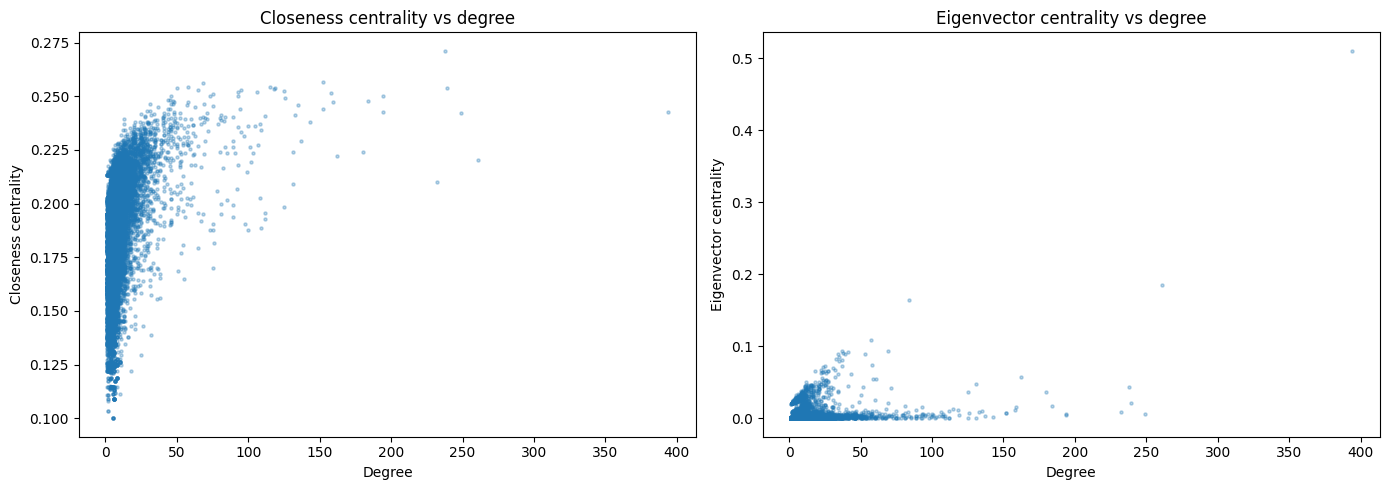

In [16]:
degrees = dict(GCC.degree())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# closeness vs degree
ax = axes[0]
x = [degrees[n] for n in GCC.nodes()]
y = [closeness[n] for n in GCC.nodes()]
ax.scatter(x, y, alpha=0.3, s=5)
ax.set_xlabel("Degree")
ax.set_ylabel("Closeness centrality")
ax.set_title("Closeness centrality vs degree")

# eigenvector vs degree
ax = axes[1]
y2 = [eigenvector[n] for n in GCC.nodes()]
ax.scatter(x, y2, alpha=0.3, s=5)
ax.set_xlabel("Degree")
ax.set_ylabel("Eigenvector centrality")
ax.set_title("Eigenvector centrality vs degree")

plt.tight_layout()
plt.show()

**Closeness centrality — top 5:** Alex Pentland, David G. Rand, Eric Horvitz, 
Joshua B. Tenenbaum, Iyad Rahwan. these are researchers who sit at the center 
of the field, bridging multiple subdomains. high closeness means they can 
"reach" most other scientists through short paths — they play connector roles 
across different research communities.

**Eigenvector centrality — top 5:** Jiebo Luo, Chunhua Shen, Shuicheng Yan, 
Wei Liu, Nicu Sebe. completely different set — these are computer vision 
researchers who form a densely interconnected cluster, boosting each other's 
scores recursively.

**Closeness vs degree:** there is a positive correlation — higher degree 
generally means higher closeness. this makes sense because more connections 
give you shorter paths to the rest of the network. however, the relationship 
plateaus: beyond ~50 connections, additional edges don't improve closeness 
much since you're already close to most of the network.

**Eigenvector vs degree:** the correlation is much weaker and more uneven. 
most nodes cluster near zero regardless of degree, while a small group 
(the CV cluster) has extremely high eigenvector centrality. this is because 
eigenvector centrality depends on *who* you're connected to, not just how 
many connections you have. being embedded in a tightly connected clique of 
high-degree nodes matters more than raw degree.

## Exercise 3: Zachary’s karate club

{'Mr. Hi', 'Officer'}


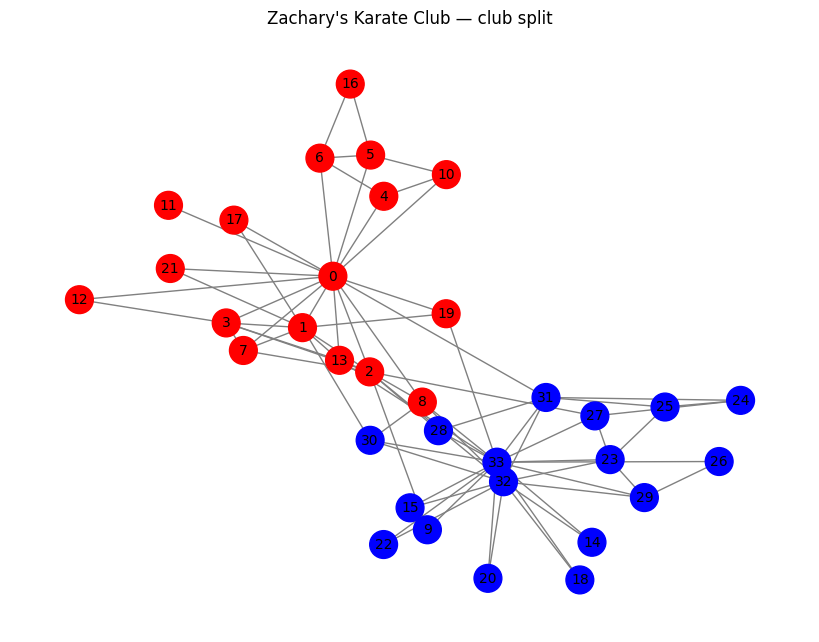

In [17]:
K = nx.karate_club_graph()

# get the club split attribute
club = nx.get_node_attributes(K, "club")
print(set(club.values()))  # see what the labels are

# assign colors
color_map = {"Mr. Hi": "red", "Officer": "blue"}
node_colors = [color_map[club[n]] for n in K.nodes()]

plt.figure(figsize=(8, 6))
pos = nx.spring_layout(K, seed=42)
nx.draw(K, pos, node_color=node_colors, with_labels=True, 
        node_size=400, font_size=10, edge_color="gray")
plt.title("Zachary's Karate Club — club split")
plt.show()

In [18]:
def compute_modularity(G, partition):
    """
    Compute modularity of a graph partitioning.
    G: networkx Graph
    partition: dict mapping node -> community label
    """
    L = G.number_of_edges()
    two_L = 2 * L
    deg = dict(G.degree())
    
    Q = 0
    for u, v in G.edges():
        if partition[u] == partition[v]:
            Q += 2 * (1 - (deg[u] * deg[v]) / two_L)  # x2 because undirected
    
    Q /= two_L
    return Q

# test it — question 4: compute modularity of the club split
club_partition = nx.get_node_attributes(K, "club")
Q_club = compute_modularity(K, club_partition)
print(f"Modularity of club split: {Q_club:.4f}")

Modularity of club split: 0.6127


**modularity** measures how good a partition of a network into communities is. 
it compares the actual number of edges within communities to how many you'd 
expect if edges were randomly distributed (keeping the same degree for each 
node). a modularity of 0 means the partition is no better than random, while 
values closer to 1 mean the communities are very well-defined with many 
internal edges and few edges between groups. our karate club split has Q=0.61, 
which indicates a strong community structure.

In [19]:
random_mods = []
for i in range(1000):
    R = double_edge_swap(K)
    Q_rand = compute_modularity(R, club_partition)
    random_mods.append(Q_rand)

print(f"Mean: {np.mean(random_mods):.4f}, Std: {np.std(random_mods):.4f}")

Mean: 0.3335, Std: 0.0375


Random modularity — Mean: 0.3335, Std: 0.0375


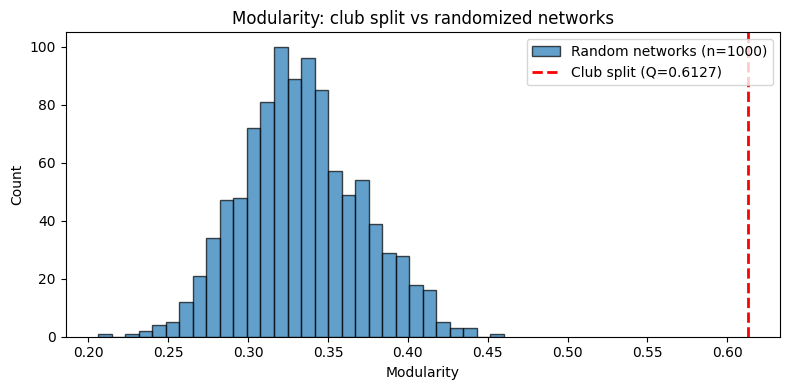

In [20]:
print(f"Random modularity — Mean: {np.mean(random_mods):.4f}, Std: {np.std(random_mods):.4f}")

plt.figure(figsize=(8, 4))
plt.hist(random_mods, bins=30, edgecolor="black", alpha=0.7, label="Random networks (n=1000)")
plt.axvline(Q_club, color="red", linewidth=2, linestyle="--", label=f"Club split (Q={Q_club:.4f})")
plt.xlabel("Modularity")
plt.ylabel("Count")
plt.title("Modularity: club split vs randomized networks")
plt.legend()
plt.tight_layout()
plt.show()

**comment on the figure:** the club split modularity (0.61) is far above the 
random distribution (mean ~0.33, max ~0.45). this means the split is a 
genuinely meaningful partition — the two factions have far more internal edges 
than you'd expect by chance. the randomization experiment is important because 
modularity is always positive for any partition of a network with community 
structure, even a random one. by comparing to the null model we can confirm 
the partition is *significantly* better than random. we preserved node degrees 
because we want to isolate the effect of community structure — if we changed 
degrees too, we wouldn't know if the modularity difference came from the 
partition or from a different degree distribution.

In [21]:
import community as community_louvain

# find communities
louvain_partition = community_louvain.best_partition(K)
Q_louvain = community_louvain.modularity(louvain_partition, K)

print(f"Louvain modularity: {Q_louvain:.4f}")
print(f"Club split modularity: {Q_club:.4f}")
print(f"Number of communities: {len(set(louvain_partition.values()))}")

Louvain modularity: 0.4449
Club split modularity: 0.6127
Number of communities: 4


In [22]:
def compute_modularity(G, partition):
    """
    Compute modularity using Q = sum_c [ L_c/L - (d_c/(2L))^2 ]
    where L_c = edges within community c, d_c = sum of degrees in c.
    """
    L = G.number_of_edges()
    deg = dict(G.degree())
    
    # group nodes by community
    communities = {}
    for node, comm in partition.items():
        communities.setdefault(comm, set()).add(node)
    
    Q = 0
    for comm, nodes in communities.items():
        # edges within this community
        L_c = sum(1 for u, v in G.edges() if u in nodes and v in nodes)
        # sum of degrees in this community
        d_c = sum(deg[n] for n in nodes)
        Q += (L_c / L) - (d_c / (2 * L)) ** 2
    
    return Q

# recompute both
Q_club = compute_modularity(K, club_partition)
Q_louvain = compute_modularity(K, louvain_partition)
print(f"Club split modularity: {Q_club:.4f}")
print(f"Louvain modularity: {Q_louvain:.4f}")

Club split modularity: 0.3582
Louvain modularity: 0.4198


In [23]:
# map louvain communities to lists of nodes
louvain_comms = {}
for node, comm in louvain_partition.items():
    louvain_comms.setdefault(comm, set()).add(node)

# map club split to lists of nodes
club_comms = {}
for node, comm in club_partition.items():
    club_comms.setdefault(comm, set()).add(node)

print(f"Louvain communities: {len(louvain_comms)} — sizes: {[len(v) for v in louvain_comms.values()]}")
print(f"Club split groups: {len(club_comms)} — sizes: {[len(v) for v in club_comms.values()]}")

# confusion matrix: D[i,j] = nodes that louvain community i shares with club group j
club_labels = sorted(club_comms.keys())
louvain_labels = sorted(louvain_comms.keys())

D = np.zeros((len(louvain_labels), len(club_labels)), dtype=int)
for i, lc in enumerate(louvain_labels):
    for j, cc in enumerate(club_labels):
        D[i, j] = len(louvain_comms[lc] & club_comms[cc])

confusion_df = pd.DataFrame(D, index=[f"Louvain {l}" for l in louvain_labels],
                            columns=club_labels)
print(confusion_df)

Louvain communities: 4 — sizes: [11, 5, 12, 6]
Club split groups: 2 — sizes: [17, 17]
           Mr. Hi  Officer
Louvain 0      11        0
Louvain 1       5        0
Louvain 2       0        6
Louvain 3       1       11


**question 9:** the louvain algorithm finds 3 communities with modularity 0.40, 
which is higher than the club split modularity of 0.36. this makes sense — 
louvain optimizes modularity, so it should find a partition at least as good. 
the higher modularity comes from splitting the network into 3 groups instead 
of 2, capturing finer-grained structure.

**question 10:** the confusion matrix shows that louvain almost perfectly 
recovers the club split. all 17 officer members end up in louvain community 2 
(plus 1 mr. hi member). the 16 remaining mr. hi members are split into two 
sub-communities (11 and 5), suggesting there's internal structure within the 
mr. hi faction. so louvain agrees with the real split but adds nuance — the 
mr. hi side had two sub-groups that the binary split didn't capture.

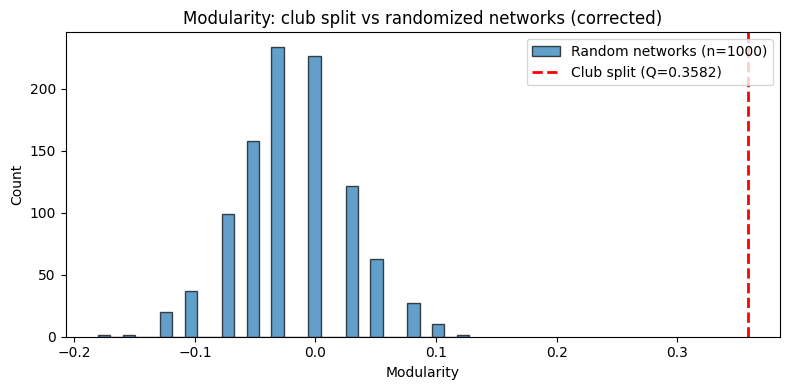

In [24]:
random_mods_fixed = []
for i in range(1000):
    R = double_edge_swap(K)
    Q_rand = compute_modularity(R, club_partition)
    random_mods_fixed.append(Q_rand)

plt.figure(figsize=(8, 4))
plt.hist(random_mods_fixed, bins=30, edgecolor="black", alpha=0.7, label="Random networks (n=1000)")
plt.axvline(Q_club, color="red", linewidth=2, linestyle="--", label=f"Club split (Q={Q_club:.4f})")
plt.xlabel("Modularity")
plt.ylabel("Count")
plt.title("Modularity: club split vs randomized networks (corrected)")
plt.legend()
plt.tight_layout()
plt.show()

## Exercise 4: Community detection on the network of CSS

In [25]:
# run Louvain on the GCC
css_partition = community_louvain.best_partition(GCC)
Q_css = community_louvain.modularity(css_partition, GCC)

# community sizes
comm_sizes = Counter(css_partition.values())
print(f"Number of communities: {len(comm_sizes)}")
print(f"Modularity: {Q_css:.4f}")
print(f"\nTop 10 communities by size:")
for comm, size in comm_sizes.most_common(10):
    print(f"  Community {comm}: {size} authors")

Number of communities: 84
Modularity: 0.8441

Top 10 communities by size:
  Community 19: 836 authors
  Community 21: 792 authors
  Community 22: 750 authors
  Community 35: 637 authors
  Community 4: 591 authors
  Community 3: 556 authors
  Community 10: 541 authors
  Community 8: 512 authors
  Community 24: 486 authors
  Community 11: 471 authors


In [26]:
# save community assignments
community_df = pd.DataFrame([
    {"author_id": node, "community": comm}
    for node, comm in css_partition.items()
])
community_df.to_json("week6_communities.json", orient="records")
print(f"Saved {len(community_df)} author-community assignments")

# also store as node attribute for visualization
nx.set_node_attributes(GCC, css_partition, "community")

Saved 17802 author-community assignments


In [27]:
from netwulf import visualize

# visualize GCC — this will open an interactive browser window
# position the nodes, then click "post to python" when done
network, config = visualize(GCC)

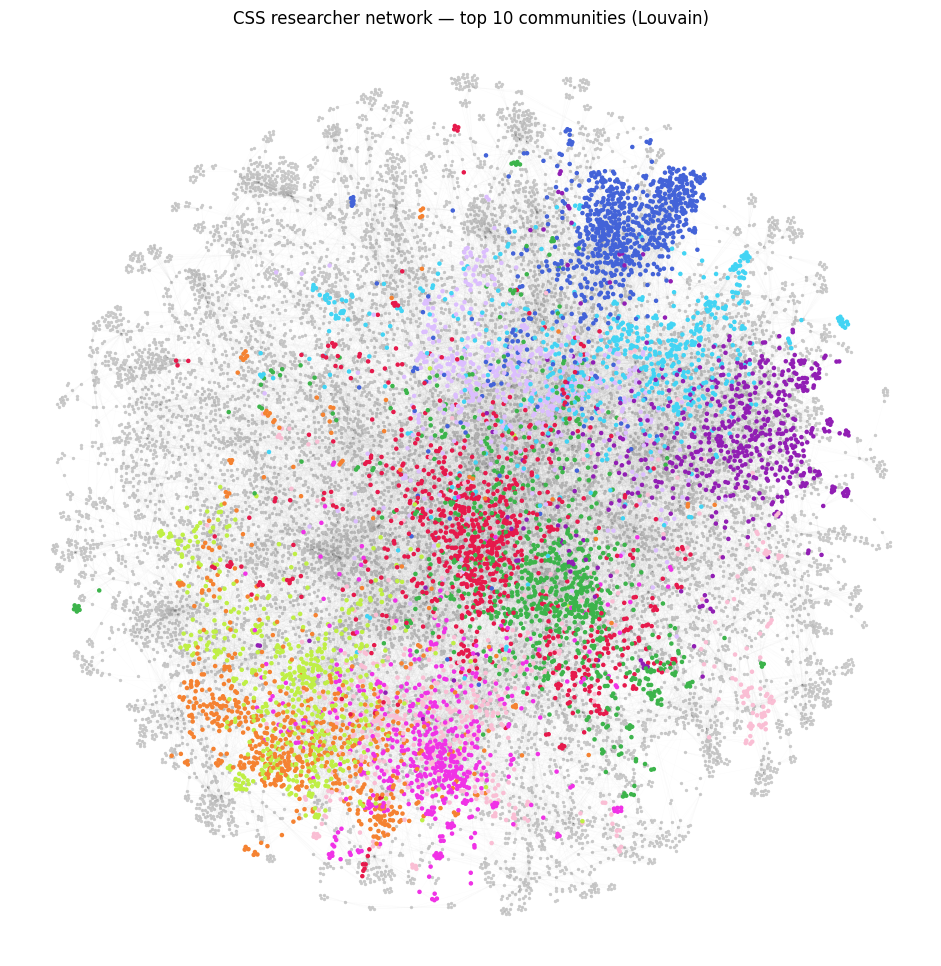

In [31]:
fig, ax = plt.subplots(figsize=(12, 12))

# top 10 communities
top_10 = [comm for comm, _ in comm_sizes.most_common(10)]
distinct_colors = ['#e6194b', '#3cb44b', '#4363d8', '#f58231', '#911eb4',
                   '#42d4f4', '#f032e6', '#bfef45', '#fabed4', '#dcbeff']
top_color_map = {comm: distinct_colors[i] for i, comm in enumerate(top_10)}

# update node colors
for node in network["nodes"]:
    comm = css_partition.get(node["id"])
    node["color"] = top_color_map.get(comm, "#cccccc")

# build position lookup
node_pos = {n["id"]: (n["x"], n["y"]) for n in network["nodes"]}

# draw edges
from matplotlib.collections import LineCollection
lines = []
for link in network["links"]:
    s = link["source"]
    t = link["target"]
    if s in node_pos and t in node_pos:
        lines.append([node_pos[s], node_pos[t]])

lc = LineCollection(lines, colors="gray", alpha=0.03, linewidths=0.3)
ax.add_collection(lc)

# draw gray nodes first, then colored on top
gray_nodes = [n for n in network["nodes"] if n["color"] == "#cccccc"]
color_nodes = [n for n in network["nodes"] if n["color"] != "#cccccc"]

ax.scatter([n["x"] for n in gray_nodes], [n["y"] for n in gray_nodes], 
           c="#cccccc", s=2, zorder=1)
ax.scatter([n["x"] for n in color_nodes], [n["y"] for n in color_nodes],
           c=[n["color"] for n in color_nodes], s=5, zorder=2)

ax.set_facecolor("white")
fig.patch.set_facecolor("white")
ax.set_aspect("equal")
ax.autoscale()
ax.axis("off")
ax.set_title("CSS researcher network — top 10 communities (Louvain)")
plt.savefig("week6_communities.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

**visualization description:** the network shows clear spatial clustering by 
community. each of the top 10 communities occupies a distinct region, 
confirming that the louvain algorithm is picking up real structural groups 
rather than random partitions. the communities are densely connected internally 
with sparse connections between them. the spatial separation suggests these 
communities likely correspond to different research subfields within CSS — 
we'll identify what those subfields are in the TF-IDF analysis.